# Import Libraries

In this notebook, we prepare the cleaned dataset for machine learning.

The required libraries are used for:

- Loading and manipulating data.
- Splitting the dataset into training and testing sets.
- Encoding categorical variables.
- Scaling numerical features.
- Building a preprocessing pipeline.
- Saving the fitted preprocessing pipeline for future predictions.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Preprocessing tools
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Save preprocessing pipeline
import joblib

# Load the Cleaned Dataset

Load the cleaned customer churn dataset that was created during the data cleaning stage.

This dataset has already been cleaned by handling missing values, removing duplicates, and correcting data types where necessary.

In [2]:
# Load the cleaned dataset
df = pd.read_csv("../data/cleaned/churn_clean.csv")

# Display the first five rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Remove Irrelevant Features

The `customerID` column is a unique identifier for each customer.

Since every customer has a different ID, this column does not contain useful information for predicting customer churn.

It is removed before model training.

In [3]:
# Remove customerID because it is not useful for prediction
df = df.drop("customerID", axis=1)

# Preview dataset
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Separate Features and Target

Machine learning models require:

- Features (`X`) → Input variables used to make predictions.
- Target (`y`) → The variable the model is trying to predict.

In this project:

- Features are all customer information.
- Target is the `Churn` column.

In [4]:
# Features
X = df.drop("Churn", axis=1)

# Target
y = df["Churn"]

# Encode the Target Variable

Most machine learning algorithms require the target variable to be numerical.

The `Churn` column is converted from:

- No → 0
- Yes → 1

This allows the model to classify customers into churn and non-churn groups.


In [5]:
# Convert target labels to numbers
y = y.map({
    "No": 0,
    "Yes": 1
})

# Check class distribution
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

# Feature Engineering

### Create Tenure Groups

Customers at different stages of their relationship with the company often behave differently.

The tenure variable is grouped into categories:

- New
- Short-term
- Medium-term
- Long-term

This new feature may help the model identify churn patterns more effectively.

In [6]:
X["TenureGroup"] = pd.cut(
    X["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["New", "Short", "Medium", "Long"],
    include_lowest=True
)

# dataset contains customers with tenure = 0 and will be included in the "New" group using **include_lowest=True**

# Create Average Monthly Spending

Customers with the same total charges may have different spending behaviour depending on how long they have been with the company.

This feature estimates the average monthly spending of each customer.

In [7]:
# Estimate average monthly spending. Adding +1 to X["tenure"] prevents division-by-zero error but
# Slightly underestimates the average monthly spending for every customer with tenure > 0.

X["AvgMonthlySpending"] = (
    X["TotalCharges"] /
    (X["tenure"] + 1)
).round(2)

# Count Total Services

Customers who subscribe to more services may be more engaged and less likely to churn.

This feature counts the number of services each customer currently uses.

In [8]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TenureGroup,AvgMonthlySpending
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,New,14.92
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,Medium,53.99
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,New,36.05
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Medium,40.02
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,New,50.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,Short,79.62
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,Long,100.86
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,New,28.87
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,New,61.32


In [9]:
X.select_dtypes(include="object").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [10]:
# Columns representing optional services
service_columns = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]
# Count subscribed services
X["TotalServices"] = (
    X[service_columns]
    .apply(lambda x: (x == "Yes").sum(), axis=1)
)

# Contract Duration Feature

### Convert Contract Type into Contract Length

The original contract column contains text categories.

A numerical version is created to represent the approximate contract duration in months.

This provides another way for the model to learn the relationship between contract length and churn.

In [11]:
# Map contract types to months
contract_map = {
    "Month-to-month": 1,
    "One year": 12,
    "Two year": 24
}

# Create numerical contract duration
X["ContractMonths"] = (
    X["Contract"].map(contract_map)
)

# Verifying multicollinearity

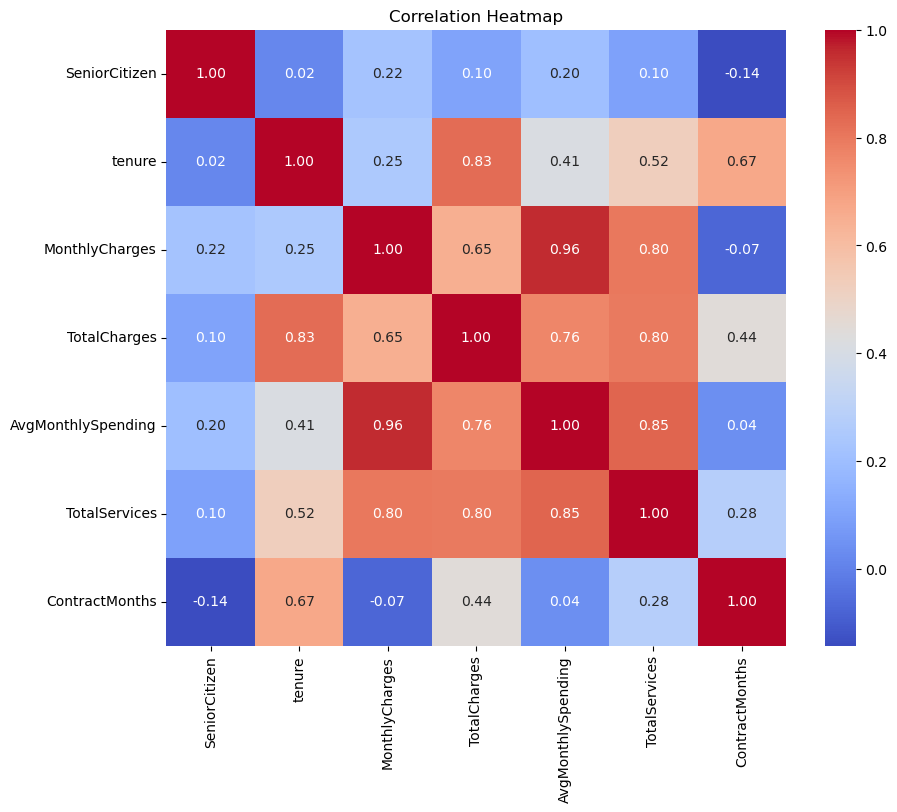

In [12]:
# Select numerical columns
num_cols = X.select_dtypes(include=["int64", "float64"])

# Correlation matrix
corr = num_cols.corr()

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# VIF

The heatmap only measures pairwise correlation (feature A vs feature B). but VIF measures whether one feature can be predicted by all the other features combined.

In [13]:
vif = pd.DataFrame()
vif["Feature"] = num_cols.columns
vif["VIF"] = [
    variance_inflation_factor(num_cols.values, i)
    for i in range(num_cols.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
4,AvgMonthlySpending,97.128576
2,MonthlyCharges,74.838873
5,TotalServices,18.343802
1,tenure,11.908658
3,TotalCharges,11.821278
6,ContractMonths,4.175307
0,SeniorCitizen,1.296862


# Drop column(s)

For a Logistic Regression model, I would remove AvgMonthlySpending and TotalCharges column because it is heavily dependent on tenure and MonthlyCharges.

It doesn't provide much new information beyond MonthlyCharges and mainly introduces multicollinearity.

In [14]:
X = X.drop(
    columns=["TotalCharges", "AvgMonthlySpending"]
)

In [15]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TenureGroup,TotalServices,ContractMonths
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,New,1,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,Medium,3,12
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,New,3,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,Medium,3,12
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,New,1,1


In [16]:
num_cols = X.select_dtypes(include=["int64", "float64"])

vif = pd.DataFrame()
vif["Feature"] = num_cols.columns
vif["VIF"] = [
    variance_inflation_factor(num_cols.values, i)
    for i in range(num_cols.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
3,TotalServices,14.484480
2,MonthlyCharges,11.789762
1,tenure,6.372306
4,ContractMonths,3.674950
0,SeniorCitizen,1.296772


# Identify Feature Types

Before preprocessing, features are separated into:

- Numerical features
- Categorical features

This allows different preprocessing techniques to be applied to each type of data.

In [17]:
# Numerical columns
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# Categorical columns
categorical_features = X.select_dtypes(include="object").columns.tolist()

# Display identified features
print(numerical_features)

print(categorical_features)

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalServices', 'ContractMonths']
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [18]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TenureGroup,TotalServices,ContractMonths
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,New,1,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,Medium,3,12
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,New,3,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,Medium,3,12
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,New,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,Short,7,12
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,Long,6,12
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,New,1,1
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,New,2,1


# Split the Dataset

The dataset is divided into:

- Training data (80%)
- Testing data (20%)

The model learns from the training data and is evaluated on unseen testing data.

Stratified sampling is used to preserve the original class distribution of the target variable.

In [19]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y # preserves the existing class distribution
)

In [20]:
# A quick way to verify that stratification worked is: The percentages should be nearly identical across all three outputs.

print(y.value_counts(normalize=True))

print(y_train.value_counts(normalize=True))

print(y_test.value_counts(normalize=True))


Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


# Create a Preprocessing Pipeline

Different preprocessing techniques are applied depending on the data type.

Numerical Features:
- StandardScaler standardizes numerical variables.

Categorical Features:
- OneHotEncoder converts categorical variables into numerical format.

ColumnTransformer combines these preprocessing steps into a single reusable pipeline.

In [21]:
# Apply preprocessing to different feature types
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="if_binary",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [22]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


# Transform the Data

The preprocessing pipeline is fitted using only the training data to prevent data leakage.

The same transformations are then applied to the testing data.

In [23]:
# Learn preprocessing parameters from training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply learned transformations to test data
X_test_processed = preprocessor.transform(X_test)

In [1]:
type(X_train_processed)

NameError: name 'X_train_processed' is not defined

In [25]:
X_processed_df = pd.DataFrame(
    X_train_processed,
    columns=preprocessor.get_feature_names_out()
)

X_processed_df.head()

,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalServices,num__ContractMonths,cat__gender_Male,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_No,...,cat__StreamingMovies_No internet service,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
0,-0.441773,0.102371,-0.521976,-0.184954,-0.820046,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.441773,-0.711743,0.337478,-0.667823,-0.820046,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.441773,-0.793155,-0.809013,-0.184954,1.586277,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.441773,-0.263980,0.284384,0.780784,1.586277,0.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
4,-0.441773,-1.281624,-0.676279,-1.150692,-0.820046,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [26]:
X_processed_df = pd.DataFrame(
    X_test_processed,
    columns=preprocessor.get_feature_names_out()
)

X_processed_df.head()

,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalServices,num__ContractMonths,cat__gender_Male,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_No,...,cat__StreamingMovies_No internet service,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
0,-0.441773,1.608483,1.629976,2.229390,1.586277,1.0,1.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
1,2.263606,-0.996684,1.168725,0.780784,-0.820046,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,-0.441773,0.346606,0.445324,1.263653,0.330804,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,-0.441773,-0.589626,0.440347,-0.184954,-0.820046,1.0,1.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.441773,1.608483,0.588013,1.746522,1.586277,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0


# Validate the Processed Dataset

After preprocessing:

- Verify the dimensions of the transformed datasets.
- Confirm that no missing values remain.

In [27]:
# Check transformed dataset shapes
print(X_train_processed.shape)

print(X_test_processed.shape)

(5634, 41)
(1409, 41)


In [28]:
# Count missing values in processed training data

print(np.isnan(X_train_processed).sum())

0


In [29]:
# Save fitted preprocessing pipeline
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

# Save train/test datasets before preprocessing
# Pipeline will handle preprocessing during training

joblib.dump(
    X_train,
    "../data/processed/X_train.pkl"
)

joblib.dump(
    X_test,
    "../data/processed/X_test.pkl"
)

joblib.dump(
    y_train,
    "../data/processed/y_train.pkl"
)

joblib.dump(
    y_test,
    "../data/processed/y_test.pkl"
)

['../data/processed/y_test.pkl']

# Save the Preprocessing Pipeline

The fitted preprocessing pipeline is saved so that the exact same transformations can be applied when making predictions on new customer data.

This ensures consistency between training and deployment.

In [30]:
# Save the fitted preprocessing pipeline

joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)
# Save processed datasets

joblib.dump(
    X_train_processed,
    "../data/processed/X_train_processed.pkl"
)

joblib.dump(
    X_test_processed,
    "../data/processed/X_test_processed.pkl"
)

['../data/processed/X_test_processed.pkl']

# Why save it?

Suppose you've trained your model and later want to predict whether a new customer will churn. Before making a prediction, the new customer's data must go through exactly the same preprocessing as the training data.

Instead of recreating the preprocessing pipeline, you simply load it:

import joblib

### Load the saved preprocessing pipeline
preprocessor = joblib.load("../models/preprocessor.pkl")

### Transform new data
new_data_processed = preprocessor.transform(new_data)

This guarantees that the transformations applied during prediction are identical to those used during training, which is essential for reliable model performance.`m